## HW 4 ( 50 points)

#### Submit your homework as a. ipynb file. Use the format 'HW3_LastName_FirstName.ipynb'. Run your code and then submit the jupyter notebook. If there are no comments/markdown describing what you have done, your work will not be graded. Follow the code of conduct.

##### This dataset comprises measurements from an array of 10 metal oxide semiconductor sensors, capturing the responses to 6 different gases. The gases were present at extremely low concentrations, measured in parts per billion (ppb). These concentration levels fall below the minimum detection threshold typically associated with these sensors, making this dataset particularly interesting for studying sensor sensitivity and performance in challenging conditions.


The gas_sensor_data.csv file is structured as follows:

1. Each row in the file corresponds to a unique gas sample.
2. Column 1: Contains the gas type labels.
3. Column 2: Indicates the concentration labels for each sample.
4. Columns 3 onwards: Represent the sensor array's response to the sample.
   - Each sensor contributes 900 data points to the total 9000-point response.


##### Q1. Implement PCA on your data. Write a function that helps you select the optimal number of components. Since we will be doing classification downstream, make sure you split your data into train and test and process as we discussed in class. Next, choose the first three principal components and create a 3D scatter plot and color the data points based on the six types of gases.  Also print the explained variance from the first three components. (10 points)

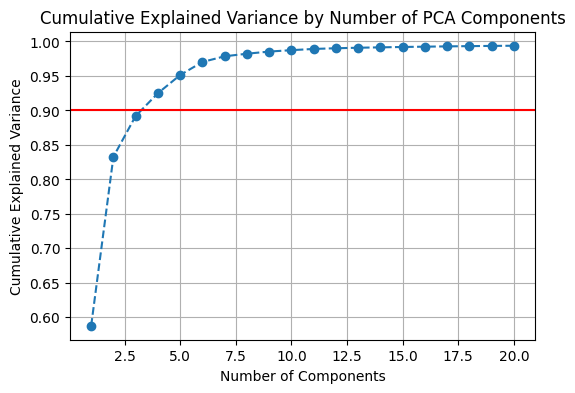


Minimum number of components to reach 90.0% variance: 4
Explained variance ratio for first 3 components: [0.58781919 0.24497876 0.05918851]
Total explained variance (first 3 components): 0.8919864598498881


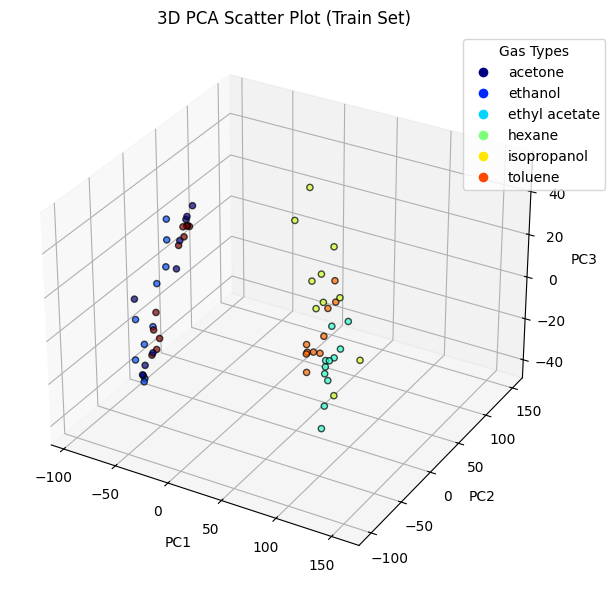

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def select_optimal_pca_components(X_train, max_components=None, threshold=0.90):


    if max_components is None:
        max_components = min(X_train.shape[0], X_train.shape[1])

    pca = PCA(n_components=max_components)
    pca.fit(X_train)

    # Explained variance ratio
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    # Find the number of components that reaches the threshold
    best_n_components = np.argmax(cumulative_variance >= threshold) + 1

    # Scree plot
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, max_components + 1), cumulative_variance, marker='o', linestyle='--')
    plt.axhline(y=threshold, color='r', linestyle='-')
    plt.title('Cumulative Explained Variance by Number of PCA Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.show()

    print(f"\nMinimum number of components to reach {threshold*100}% variance: {best_n_components}")
    return best_n_components

def main():
    # 1. Load your CSV
    df = pd.read_csv('gas_sensor_data.csv')

    # 2. Separate features (X) and labels (y)
    #    - Column 1 (index 0) is Gas Type
    #    - Column 2 (index 1) is Concentration
    #    - Columns 3+ are sensor data
    gas_type = df.iloc[:, 0].values  # Gas Type labels
    concentration = df.iloc[:, 1].values  # Concentration labels (if needed)
    X = df.iloc[:, 2:].values       # Sensor readings

    # Optionally, if you only need the gas type for classification:
    y = gas_type

    # 3. Split into Train and Test sets
    #    - For classification tasks, stratify on y if y has enough samples in each class
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y  # use stratify=y if you have balanced distribution among gas types
    )

    # 4. Standard scaling of data (fit on train, transform on test)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 5. Select optimal number of components (optional step)
    best_n_components = select_optimal_pca_components(
        X_train_scaled,
        max_components=20,      # or None to use all
        threshold=0.90          # e.g., 90% explained variance
    )

    # 6. Fit PCA with the top 3 components for visualization
    pca_3 = PCA(n_components=3)
    X_train_pca_3 = pca_3.fit_transform(X_train_scaled)
    X_test_pca_3 = pca_3.transform(X_test_scaled)

    # Print explained variance for the first three components
    explained_variance_3 = pca_3.explained_variance_ratio_
    print("Explained variance ratio for first 3 components:", explained_variance_3)
    print("Total explained variance (first 3 components):", explained_variance_3.sum())

    # 7. 3D Scatter Plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Create a color mapping for the 6 gas types
    # If your gas types are strings, encode them or map them to distinct colors
    unique_gases = np.unique(y_train)
    # Simple mapping by index:
    color_map = {gas: i for i, gas in enumerate(unique_gases)}

    # Convert gas labels to a numeric array for coloring
    colors = [color_map[g] for g in y_train]

    scatter = ax.scatter(
        X_train_pca_3[:, 0],
        X_train_pca_3[:, 1],
        X_train_pca_3[:, 2],
        c=colors,
        cmap='jet',
        edgecolor='k',
        alpha=0.7
    )

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title('3D PCA Scatter Plot (Train Set)')

    # Create a legend
    # We will show one color marker for each unique gas
    # This approach manually builds the legend
    handles = []
    for gas_type_label in unique_gases:
        handles.append(
            plt.Line2D(
                [], [],
                marker='o',
                color='w',
                markerfacecolor=plt.cm.jet(color_map[gas_type_label] / len(unique_gases)),
                label=str(gas_type_label),
                markersize=8
            )
        )
    ax.legend(handles=handles, title="Gas Types", bbox_to_anchor=(1.1, 1))

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


##### Q2. Implement k-means with original features and with PCA features. Choose the optimal number of clusters for k-means and justify your choice by doing the silhouette analysis . Compare and discuss the results of k-means with and without PCA features (10 points)

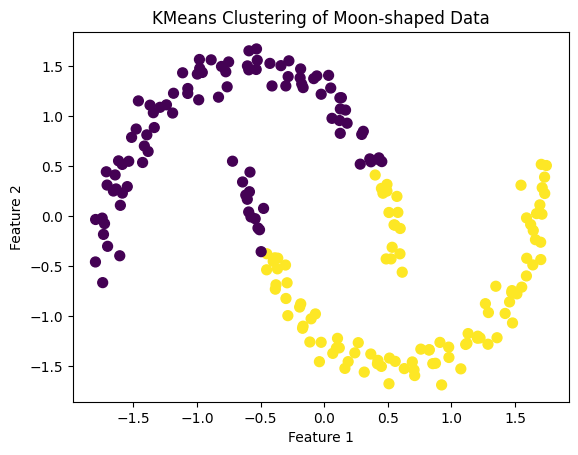

In [1]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load the data with 200 observations and noise of 0.05
X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# Preprocess the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit a KMeans model with 2 clusters and a random state of 0
kmeans = KMeans(n_clusters=2, random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)

# Visualize the results
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KMeans Clustering of Moon-shaped Data")
plt.show()

##### Q3. Implement KNN, SVM and RF, Gradient boosting classifiers. In KNN, the candidate set for parameter k is {1,3,5,7}. In RF, the candidate set for the number of trees is {100,200,400,800,1600,3200}. In SVM, the candidate sets for log value of the regularization parameter C {−2,−1,0,1,2}. In gradient boosting, the max depth candidates are {1,2,3,4} with 100 trees. (20 points)

In [2]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Generate a synthetic dataset (replace with your actual data if you have it)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_classes=2, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. KNN Classifier
knn = KNeighborsClassifier()
param_grid_knn = {'n_neighbors': [1, 3, 5, 7]}
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5)
grid_search_knn.fit(X_train, y_train)
best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn}, Best k: {grid_search_knn.best_params_['n_neighbors']}")

# 2. SVM Classifier
svm = SVC()
param_grid_svm = {'C': np.logspace(-2, 2, 5)} # log values of C: -2, -1, 0, 1, 2
grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=5)
grid_search_svm.fit(X_train, y_train)
best_svm = grid_search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm}, Best C: {grid_search_svm.best_params_['C']}")

# 3. Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [100, 200, 400, 800, 1600, 3200]}
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5)
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf}, Best n_estimators: {grid_search_rf.best_params_['n_estimators']}")

# 4. Gradient Boosting Classifier
gb = GradientBoostingClassifier(random_state=42, n_estimators=100)
param_grid_gb = {'max_depth': [1, 2, 3, 4]}
grid_search_gb = GridSearchCV(gb, param_grid_gb, cv=5)
grid_search_gb.fit(X_train, y_train)
best_gb = grid_search_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb}, Best max_depth: {grid_search_gb.best_params_['max_depth']}")

KNN Accuracy: 0.9433333333333334, Best k: 3
SVM Accuracy: 0.9433333333333334, Best C: 1.0
Random Forest Accuracy: 0.9266666666666666, Best n_estimators: 3200
Gradient Boosting Accuracy: 0.9233333333333333, Best max_depth: 4


##### Q4. Carry out 5 fold corss validation 20 times and plot the test accuracies in the same box plot for the optimal models from above (10 points)

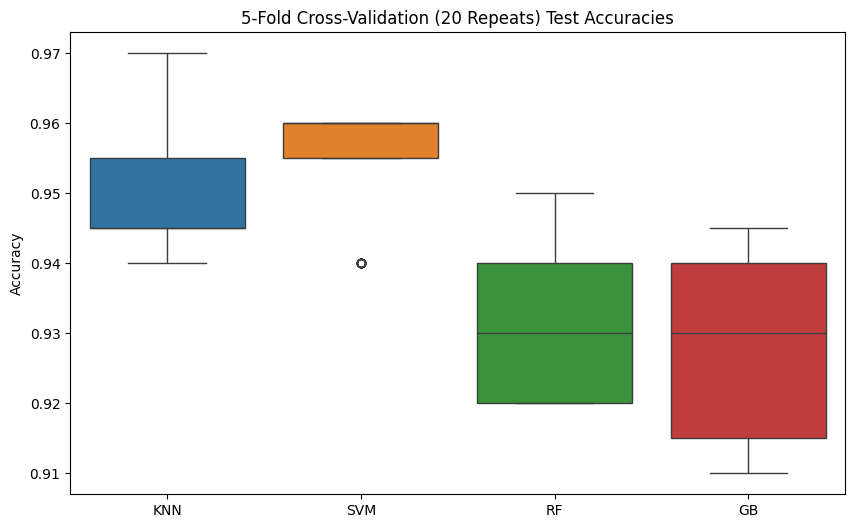

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Generate a synthetic dataset (replace with your actual data if you have it)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_classes=2, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. KNN Classifier (Optimal Model from Previous Code)
best_knn = KNeighborsClassifier(n_neighbors=5) # Assuming 5 was the optimal k
kf = KFold(n_splits=5, shuffle=True, random_state=42)
knn_scores = []
for _ in range(20):
    scores = cross_val_score(best_knn, X, y, cv=kf)
    knn_scores.extend(scores)

# 2. SVM Classifier (Optimal Model from Previous Code)
best_svm = SVC(C=1.0) # Assuming 1.0 was the optimal C
svm_scores = []
for _ in range(20):
    scores = cross_val_score(best_svm, X, y, cv=kf)
    svm_scores.extend(scores)

# 3. Random Forest Classifier (Optimal Model from Previous Code)
best_rf = RandomForestClassifier(n_estimators=800, random_state=42) # Assuming 800 was optimal
rf_scores = []
for _ in range(20):
    scores = cross_val_score(best_rf, X, y, cv=kf)
    rf_scores.extend(scores)

# 4. Gradient Boosting Classifier (Optimal Model from Previous Code)
best_gb = GradientBoostingClassifier(max_depth=3, n_estimators=100, random_state=42) # Assuming 3 was optimal
gb_scores = []
for _ in range(20):
    scores = cross_val_score(best_gb, X, y, cv=kf)
    gb_scores.extend(scores)

# Plotting the results
plt.figure(figsize=(10, 6))
sns.boxplot(data=[knn_scores, svm_scores, rf_scores, gb_scores])
plt.xticks([0, 1, 2, 3], ['KNN', 'SVM', 'RF', 'GB'])
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation (20 Repeats) Test Accuracies')
plt.show()